In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# End-to-end: extract UNI v1 embeddings for all breast cancer
# samples in HEST1k, saving features to Google Drive
# ============================================================

# ---------- 0. Mount Google Drive ----------
from google.colab import drive
drive.mount('/content/drive')

# ---------- 1. Imports & auth ----------
import pandas as pd
import torch, timm, h5py, numpy as np
from torchvision import transforms
from huggingface_hub import login, snapshot_download, hf_hub_download
from pathlib import Path
from tqdm import tqdm
import os

login(token=HF_TOKEN)  # needs access to MahmoodLab/hest AND MahmoodLab/UNI

# ---------- 2. Find breast cancer sample IDs ----------
meta_df = pd.read_csv("hf://datasets/MahmoodLab/hest/HEST_v1_3_0.csv")
breast = meta_df[meta_df['organ'] == 'Breast']
breast_cancer = breast[breast['disease_state'] == 'Cancer']
print(f"Cancer-only breast samples: {len(breast_cancer)}")

ids = breast_cancer['id'].tolist()

# ---------- 3. Load UNI v1 ----------
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

ckpt = hf_hub_download("MahmoodLab/UNI", filename="pytorch_model.bin")
model = timm.create_model(
    "vit_large_patch16_224", img_size=224, patch_size=16,
    init_values=1e-5, num_classes=0, dynamic_img_size=True,
)
model.load_state_dict(torch.load(ckpt, map_location="cpu"), strict=True)
model.eval().to(device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

# ---------- 4. Set up dirs ----------
# Raw patches → ephemeral Colab disk (deleted after each sample)
# UNI features → Google Drive (persistent)
patch_dir = Path("hest_data/patches")
patch_dir.mkdir(parents=True, exist_ok=True)

out_dir = Path("/content/drive/MyDrive/hest_uni_features")
out_dir.mkdir(parents=True, exist_ok=True)
print(f"Saving features to: {out_dir}")

BATCH = 64

# ---------- 5. Loop: download → extract → save to Drive → delete raw ----------
for sample_id in tqdm(ids, desc="Samples"):
    out_path = out_dir / f"{sample_id}_Patches_UNI.h5"
    if out_path.exists():
        print(f"  skip {sample_id} (already done)")
        continue

    # download just this sample's patches
    snapshot_download(
        repo_id="MahmoodLab/hest",
        repo_type="dataset",
        allow_patterns=[f"patches/{sample_id}.h5"],
        local_dir="hest_data",
    )

    in_path = patch_dir / f"{sample_id}.h5"
    if not in_path.exists():
        print(f"  WARNING: {sample_id} download failed, skipping")
        continue

    # load patches
    with h5py.File(in_path, "r") as f:
        imgs = f["img"][:]
        coords = f["coords"][:]
        barcodes = f["barcode"][:]

    # extract UNI features
    feats = []
    with torch.inference_mode():
        for i in range(0, len(imgs), BATCH):
            batch = torch.stack([transform(img) for img in imgs[i:i+BATCH]]).to(device)
            feats.append(model(batch).cpu().numpy())
    feats = np.concatenate(feats, axis=0)

    # save to Google Drive
    with h5py.File(out_path, "w") as f:
        f.create_dataset("features", data=feats)
        f.create_dataset("coords", data=coords)
        f.create_dataset("barcode", data=barcodes)
        f.attrs["model"] = "UNI_v1"
        f.attrs["embed_dim"] = feats.shape[1]
        f.attrs["source_sample"] = sample_id

    # delete raw patches from local disk to save space
    os.remove(in_path)

    print(f"  ✓ {sample_id}: {feats.shape}")

print(f"\nDone. Features saved to: {out_dir}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cancer-only breast samples: 139
Device: cuda
Saving features to: /content/drive/MyDrive/hest_uni_features



Samples:   0%|          | 0/139 [00:00<?, ?it/s]

Fetching ... files: 0it [00:00, ?it/s]


Samples:   1%|          | 1/139 [00:16<38:54, 16.92s/it]

...


Samples:  99%|█████████▉| 138/139 [26:49<00:23, 23.89s/it]

  ✓ NCBI783: (3501, 1024)


Fetching ... files: 0it [00:00, ?it/s]


Samples: 100%|██████████| 139/139 [27:12<00:00, 11.75s/it]

  ✓ NCBI776: (4973, 1024)

Done. Features saved to: /content/drive/MyDrive/hest_uni_features


Found 139 sample files
  NCBI776: 4973 patches
  NCBI783: 3501 patches
  NCBI784: 2901 patches
  NCBI785: 4074 patches
  SPA0: 262 patches
  SPA100: 695 patches
  SPA101: 691 patches
  SPA102: 570 patches
  SPA103: 572 patches
  SPA104: 587 patches
  SPA105: 437 patches
  SPA106: 428 patches
  SPA107: 431 patches
  SPA108: 399 patches
  SPA109: 423 patches
  SPA110: 412 patches
  SPA111: 297 patches
  SPA112: 292 patches
  SPA113: 318 patches
  SPA114: 301 patches
  SPA115: 316 patches
  SPA116: 355 patches
  SPA117: 331 patches
  SPA118: 256 patches
  SPA119: 510 patches
  SPA120: 602 patches
  SPA121: 613 patches
  SPA122: 463 patches
  SPA123: 462 patches
  SPA124: 440 patches
  SPA125: 712 patches
  SPA126: 695 patches
  SPA127: 691 patches
  SPA128: 570 patches
  SPA129: 572 patches
  SPA130: 587 patches
  SPA131: 315 patches
  SPA132: 306 patches
  SPA133: 302 patches
  SPA134: 301 patches
  SPA135: 303 patches
  SPA136: 306 patches
  SPA137: 178 patches
  SPA138: 181 patches
  S

/tmp/ipykernel_23475/2739715854.py:46: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5, key_added="leiden")



Leiden clusters found: 37
leiden
0     31988
1     16795
2     15505
3     14454
4     11062
5     10633
6      9847
7      8972
8      8554
9      7656
10     7327
11     6972
12     6964
13     5893
14     4978
15     4832
16     4722
17     4547
18     4205
19     4023
20     3944
21     3519
22     3492
23     3332
24     3290
25     3057
26     2808
27     2681
28     2516
29     2339
30     1901
31     1814
32     1737
33     1621
34     1134
35      148
36       38
Name: count, dtype: int64
Unique patients: 139


/tmp/ipykernel_23475/2739715854.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_base = plt.cm.get_cmap("tab20", n_patients) if n_patients <= 20 else plt.cm.get_cmap("hsv", n_patients)
/tmp/ipykernel_23475/2739715854.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cluster_cmap = plt.cm.get_cmap("tab20", n_clusters)


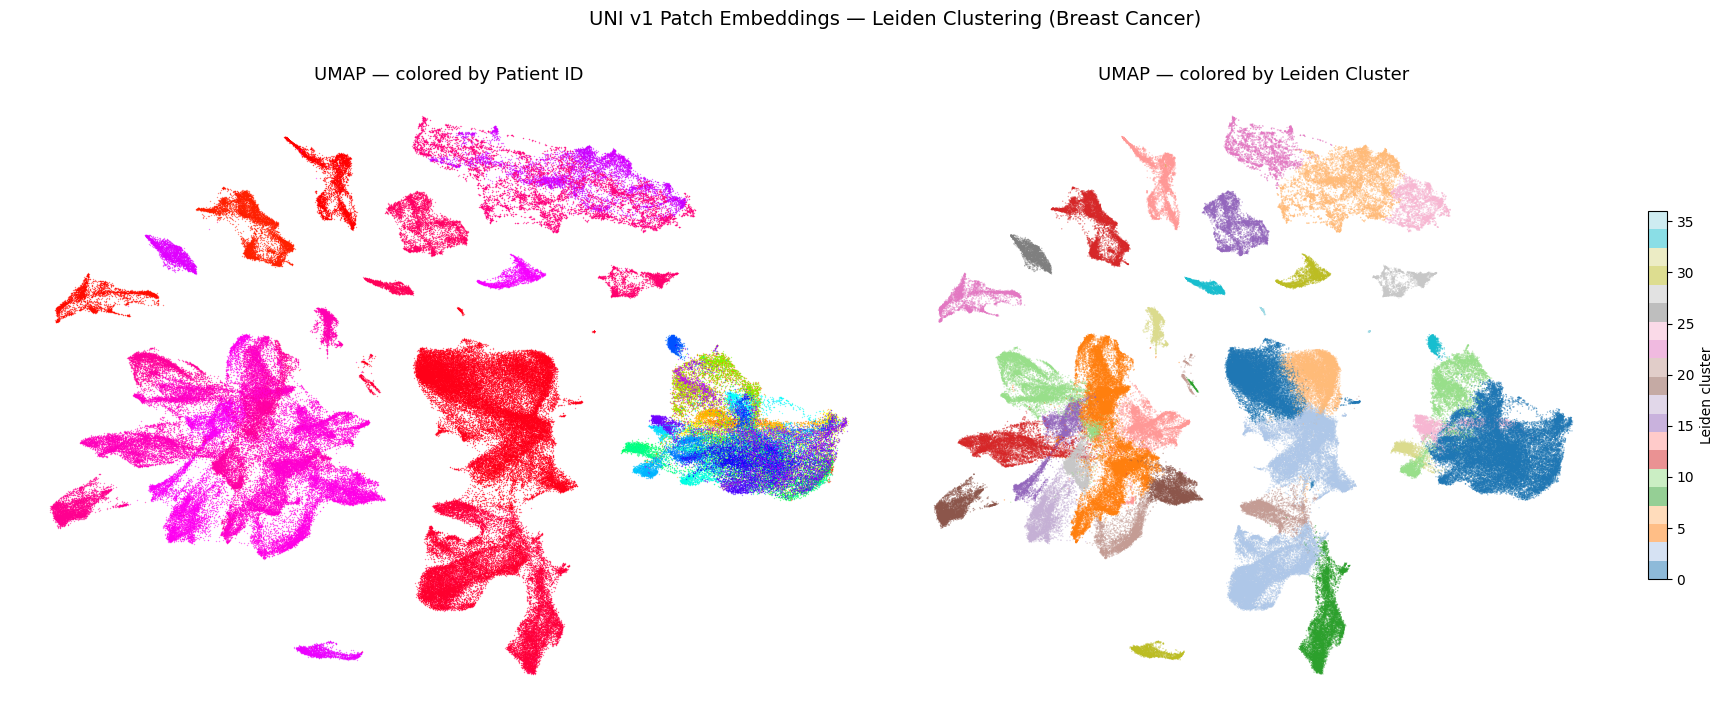

Plot saved to Drive.

=== Patient Mixing per Leiden Cluster ===
leiden  patient_entropy_bits  n_patients_in_cluster  n_patches_total
     0              6.493214                    108            31988
     1              1.001617                      3            16795
     2              1.184126                      6            15505
     3              1.033111                      6            14454
     4              2.299746                     13            11062
     5              1.123209                     11            10633
     6              1.986273                      4             9847
     7              1.000966                      3             8972
     8              1.014511                      5             8554
     9              1.098238                      8             7656
    10              4.456523                     70             7327
    11              0.983091                      4             6972
    12              0.072827           

/tmp/ipykernel_23475/2739715854.py:114: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mix_df.groupby("leiden")
/tmp/ipykernel_23475/2739715854.py:115: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(cluster_entropy)
/tmp/ipykernel_23475/2739715854.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mix_df.groupby("lei

In [ ]:
# ============================================================
# Leiden clustering on pooled UNI v1 embeddings + UMAP viz
# colored by patient ID
# ============================================================

# ---------- 0. Install dependencies ----------
!pip install -q umap-learn leidenalg igraph scanpy

# ---------- 1. Imports ----------
import h5py
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scanpy as sc
import anndata as ad

# ---------- 2. Load all embeddings from Drive ----------
feat_dir = Path("/content/drive/MyDrive/hest_uni_features")
h5_files = sorted(feat_dir.glob("*_Patches_UNI.h5"))
print(f"Found {len(h5_files)} sample files")

all_feats = []
all_patient_ids = []

for h5_path in h5_files:
    sample_id = h5_path.stem.replace("_Patches_UNI", "")
    with h5py.File(h5_path, "r") as f:
        feats = f["features"][:]           # (N_patches, embed_dim)
    all_feats.append(feats)
    all_patient_ids.extend([sample_id] * len(feats))
    print(f"  {sample_id}: {feats.shape[0]} patches")

X = np.concatenate(all_feats, axis=0)     # (total_patches, embed_dim)
patient_ids = np.array(all_patient_ids)
print(f"\nTotal patches: {X.shape[0]}, Embedding dim: {X.shape[1]}")

# ---------- 3. Build AnnData & run Scanpy Leiden pipeline ----------
adata = ad.AnnData(X=X.astype(np.float32))
adata.obs["patient_id"] = pd.Categorical(patient_ids)

# PCA → kNN graph → Leiden clustering
sc.pp.pca(adata, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50, metric="cosine")
sc.tl.leiden(adata, resolution=0.5, key_added="leiden")
sc.tl.umap(adata, min_dist=0.3, spread=1.0)

print(f"\nLeiden clusters found: {adata.obs['leiden'].nunique()}")
print(adata.obs["leiden"].value_counts())

# ---------- 4. Plot: UMAP colored by patient ID ----------
n_patients = adata.obs["patient_id"].nunique()
print(f"Unique patients: {n_patients}")

# Build a discrete colormap with enough colors
cmap_base = plt.cm.get_cmap("tab20", n_patients) if n_patients <= 20 else plt.cm.get_cmap("hsv", n_patients)
palette = {pid: mcolors.to_hex(cmap_base(i)) for i, pid in enumerate(adata.obs["patient_id"].cat.categories)}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Panel A: colored by patient ID ---
umap_coords = adata.obsm["X_umap"]
ax = axes[0]
for pid, color in palette.items():
    mask = patient_ids == pid
    ax.scatter(umap_coords[mask, 0], umap_coords[mask, 1],
               c=color, label=pid, s=1, alpha=0.5, linewidths=0)
ax.set_title("UMAP — colored by Patient ID", fontsize=13)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.axis("off")
# Legend only feasible if few patients
if n_patients <= 20:
    ax.legend(markerscale=6, bbox_to_anchor=(1.01, 1), loc="upper left",
              fontsize=8, frameon=False, title="Patient ID")

# --- Panel B: colored by Leiden cluster ---
leiden_labels = adata.obs["leiden"].values.astype(int)
n_clusters = leiden_labels.max() + 1
cluster_cmap = plt.cm.get_cmap("tab20", n_clusters)
cluster_colors = [cluster_cmap(i) for i in leiden_labels]
sc_b = axes[1].scatter(umap_coords[:, 0], umap_coords[:, 1],
                        c=leiden_labels, cmap="tab20",
                        s=1, alpha=0.5, linewidths=0)
axes[1].set_title("UMAP — colored by Leiden Cluster", fontsize=13)
axes[1].set_xlabel("UMAP 1"); axes[1].set_ylabel("UMAP 2")
axes[1].axis("off")
plt.colorbar(sc_b, ax=axes[1], label="Leiden cluster", shrink=0.6)

plt.suptitle("UNI v1 Patch Embeddings — Leiden Clustering (Breast Cancer)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/hest_uni_features/leiden_umap_patient_colored.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to Drive.")

# ---------- 5. Patient mixing table per cluster ----------
mix_df = (
    adata.obs
    .groupby(["leiden", "patient_id"], observed=True)
    .size()
    .reset_index(name="n_patches")
)

# Entropy of patient distribution per cluster (higher = better mixing)
from scipy.stats import entropy

def cluster_entropy(group):
    counts = group["n_patches"].values
    p = counts / counts.sum()
    return entropy(p, base=2)

entropy_df = (
    mix_df.groupby("leiden")
    .apply(cluster_entropy)
    .reset_index(name="patient_entropy_bits")
)
entropy_df["n_patients_in_cluster"] = (
    mix_df.groupby("leiden")["patient_id"].nunique().values
)
entropy_df["n_patches_total"] = (
    mix_df.groupby("leiden")["n_patches"].sum().values
)

print("\n=== Patient Mixing per Leiden Cluster ===")
print(entropy_df.to_string(index=False))
entropy_df.to_csv("/content/drive/MyDrive/breast_leiden_patient_mixing.csv", index=False)
print("\nMixing stats saved.")

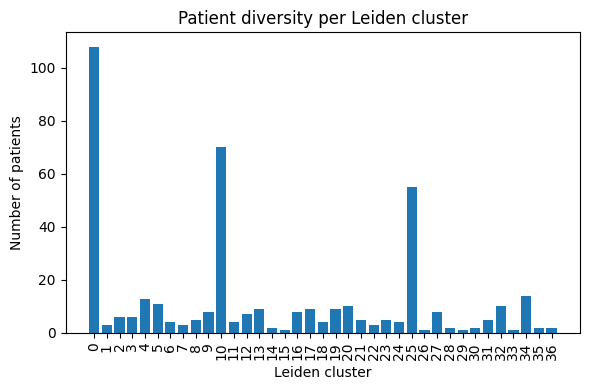

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(patients_per_cluster.index.astype(str), patients_per_cluster.values)

plt.xlabel("Leiden cluster")
plt.ylabel("Number of patients")
plt.title("Patient diversity per Leiden cluster")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Downloading the H5AD and getting the top genes

In [ ]:
# # Download H5AD spot files for breast cancer samples
# for sample_id in tqdm(ids, desc="H5AD"):
#     out_path = Path(f"/content/drive/MyDrive/hest_h5ad/{sample_id}.h5ad")
#     out_path.parent.mkdir(parents=True, exist_ok=True)
#     if out_path.exists():
#         print(f"  skip {sample_id}")
#         continue

#     snapshot_download(
#         repo_id="MahmoodLab/hest",
#         repo_type="dataset",
#         allow_patterns=[f"st/{sample_id}.h5ad"],
#         local_dir="hest_data",
#     )

#     src = Path(f"hest_data/st/{sample_id}.h5ad")
#     if not src.exists():
#         print(f"  WARNING: {sample_id} not found")
#         continue

#     import shutil
#     shutil.move(str(src), str(out_path))
#     print(f"  ✓ {sample_id}")

In [ ]:
# # ============================================================
# # Map Leiden clusters → H5AD spots → Differential Expression
# # ============================================================

# import scanpy as sc
# import h5py
# import numpy as np
# import pandas as pd
# from pathlib import Path
# from tqdm import tqdm

# # ---------- 1. Build barcode → leiden cluster lookup ----------
# # adata already has leiden clusters from previous cell
# # We need to reconstruct which barcode belongs to which cluster

# feat_dir = Path("/content/drive/MyDrive/hest_uni_features")
# h5ad_dir = Path("/content/drive/MyDrive/hest_h5ad")

# all_barcodes = []
# all_sample_ids = []

# h5_files = sorted(feat_dir.glob("*_Patches_UNI.h5"))
# for h5_path in h5_files:
#     sample_id = h5_path.stem.replace("_Patches_UNI", "")
#     with h5py.File(h5_path, "r") as f:
#         barcodes = f["barcode"][:].astype(str)
#     all_barcodes.extend(barcodes)
#     all_sample_ids.extend([sample_id] * len(barcodes))

# # Build a DataFrame aligning barcodes with leiden clusters
# patch_df = pd.DataFrame({
#     "barcode": all_barcodes,
#     "sample_id": all_sample_ids,
#     "leiden": adata.obs["leiden"].values  # from your clustering cell
# })
# print(f"Total patch-barcode-cluster mappings: {len(patch_df)}")

# # ---------- 2. Load H5ADs and attach cluster labels ----------
# st_adatas = []

# for sample_id in tqdm(ids, desc="Loading H5AD"):
#     h5ad_path = h5ad_dir / f"{sample_id}.h5ad"
#     if not h5ad_path.exists():
#         continue

#     st = sc.read_h5ad(h5ad_path)
#     st.obs["sample_id"] = sample_id

#     # Filter patch_df to this sample
#     sample_patches = patch_df[patch_df["sample_id"] == sample_id].copy()
#     sample_patches = sample_patches.drop_duplicates("barcode").set_index("barcode")

#     # Match barcodes — st.obs_names are the spot barcodes
#     common = st.obs_names.intersection(sample_patches.index)
#     st = st[common].copy()
#     st.obs["leiden"] = sample_patches.loc[common, "leiden"].values

#     st_adatas.append(st)

# # ---------- 3. Concatenate all ST data ----------
# combined_st = sc.concat(st_adatas, label="sample_id", keys=[a.obs["sample_id"].iloc[0] for a in st_adatas])
# print(f"Combined ST adata: {combined_st.shape}")
# print(f"Leiden clusters present: {combined_st.obs['leiden'].nunique()}")

# # ---------- 4. Normalize gene expression ----------
# sc.pp.normalize_total(combined_st, target_sum=1e4)
# sc.pp.log1p(combined_st)

# # ---------- 5. Differential expression across Leiden clusters ----------
# sc.tl.rank_genes_groups(
#     combined_st,
#     groupby="leiden",
#     method="wilcoxon",
#     key_added="leiden_de",
#     n_genes=20
# )

# # ---------- 6. Show top genes for high-mixing vs low-mixing clusters ----------
# high_mix_clusters = ["0", "10", "25"]   # high entropy from your table
# low_mix_clusters  = ["15", "26", "29", "33"]  # entropy = 0, single patient

# print("\n=== Top DE genes — HIGH MIXING clusters (morphology-driven) ===")
# for c in high_mix_clusters:
#     genes = sc.get.rank_genes_groups_df(combined_st, group=c, key="leiden_de").head(10)
#     print(f"\nCluster {c}:")
#     print(genes[["names", "scores", "pvals_adj"]].to_string(index=False))

# print("\n=== Top DE genes — LOW MIXING clusters (patient-specific) ===")
# for c in low_mix_clusters:
#     genes = sc.get.rank_genes_groups_df(combined_st, group=c, key="leiden_de").head(10)
#     print(f"\nCluster {c}:")
#     print(genes[["names", "scores", "pvals_adj"]].to_string(index=False))

# # ---------- 7. Save results ----------
# de_results = []
# for c in combined_st.obs["leiden"].unique():
#     df = sc.get.rank_genes_groups_df(combined_st, group=c, key="leiden_de").head(20)
#     df["leiden_cluster"] = c
#     de_results.append(df)

# de_df = pd.concat(de_results)
# de_df.to_csv("/content/drive/MyDrive/hest_uni_features/leiden_DE_genes.csv", index=False)
# print("\nDE results saved.")

# # ---------- 8. Optional: dotplot of top genes ----------
# sc.pl.rank_genes_groups_dotplot(
#     combined_st,
#     key="leiden_de",
#     n_genes=5,
#     groupby="leiden",
#     save="_leiden_top5_genes.png"
# )